In [1]:
%pip install unidecode


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import unidecode
import seaborn as sns

In [3]:
valid_days = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado"]
get_valid_day = lambda day: next(filter(lambda valid_day: unidecode.unidecode(day.strip()).startswith(unidecode.unidecode(valid_day)), valid_days), None)
is_valid_day = lambda day: any(filter(lambda valid_day: unidecode.unidecode(day.strip()).startswith(unidecode.unidecode(valid_day)), valid_days))

df = pd.read_csv("../data/evaluaciones_docentes_sintetica_ampliada.csv", sep=",", encoding="utf-8", header="infer", dtype={
    "id_docente": "category",
    "tendencia_desempeno": "category",
    "comentario": "category",
    "asignatura": "category",
    "franja_horaria": "category",
    "id_curso_grupo": "category",
    "clases_dictadas": "Int64",
    "clases_pactadas": "Int64",
    "numero_estudiantes_aprobaron": "Int64",
    "numero_estudiantes_perdieron": "Int64",
    "numero_estudiantes_desistieron": "Int64",
    "promedio_asistencias_estudiantes": "Float64",
}, converters={
    # Hay semestres donde el docente deja de dictar una materia y necesita agregarse el semestre artificialmente.
    # Por tanto, se agrega esta transformación para más adelante apoyar a la completacion de ceros en semestres faltantes.
    "semestre": lambda s: pd.Period(s.strip().replace("-1", "Q1").replace("-2", "Q3"), freq="2Q-DEC"),
    "hora_inicio": lambda val: pd.to_datetime(val, format="%H:%M").time(),
    "hora_fin": lambda val: pd.to_datetime(val, format="%H:%M").time(),
    "dias_clase": lambda dias: tuple(get_valid_day(dia) for dia in dias.split("-") if is_valid_day(dia)),
})
df = df.convert_dtypes()

df["Cantidad de Clases Semanales"] = df["dias_clase"].apply(lambda dias: len(dias)).astype("Int64")
df["Horas Por Clase"] = ((pd.to_timedelta(df["hora_fin"].astype(str)) - pd.to_timedelta(df["hora_inicio"].astype(str))).dt.total_seconds() / 3600).astype("Int64")

# Horas efectivas de operación dirigidas a los estudiantes en el aula
df["Horas Lectivas Totales"] = df["clases_dictadas"] * df["Horas Por Clase"]
df["Horas Lectivas Por Semana"] = df["Cantidad de Clases Semanales"] * df["Horas Por Clase"]

df.dtypes

id_curso_grupo                            category
id_docente                                category
asignatura                                category
semestre                            period[2Q-DEC]
numero_estudiantes                           Int64
puntaje_claridad                           Float64
puntaje_metodologia                        Float64
puntaje_evaluacion                         Float64
comentario                                category
tendencia_desempeno                       category
clases_pactadas                              Int64
clases_dictadas                              Int64
porcentaje_cumplimiento_clases             Float64
dias_clase                                  object
hora_inicio                                 object
hora_fin                                    object
franja_horaria                            category
horario_clases                              string
promedio_asistencias_estudiantes           Float64
porcentaje_promedio_asistencia 


**Se evidencia que la cantidad de clases pactadas es igual a 16 veces la cantidad de clases semanales, es decir que hay 16 semanas proyectadas para cada grupo.**

**En la práctica quizás reponen una o varias semanas adicionales para garantizar el cumplimiento de horas: bien sea para reponer días compensados del docente, días festivos, situaciones de fuerza mayor, etc.**



In [4]:
df["Horas Lectivas Teóricas"] = 16 * df["Horas Lectivas Por Semana"]
df["Horas Lectivas Planeadas"] = df["clases_pactadas"] * df["Horas Por Clase"]

(df["Horas Lectivas Teóricas"] == df["Horas Lectivas Planeadas"]).all()


np.True_


**Validando la relación de horas efectivas y planeadas, se aprecia un 64% de casos en donde se incumplió con lo pactado.**


In [5]:
porcentaje_casos_incumplimiento = 100 * len(df[df["Horas Lectivas Totales"] < df["Horas Lectivas Planeadas"]]) / len(df)

porcentaje_casos_incumplimiento

64.03333333333333

**Se aprecia que el 41.4% de los grupos habrían subsanado la brecha de horas con 1 semana extra de clases, ya que corresponden a plazos alcanzables según el horario lectivo.**

**Así mismo, existe un 16.3% de grupos que habrían necesitado dos semanas más para dar cumplimiento a las horas faltantes.**

**Por último, el 6.3% de grupos habrían necesitado mucho más tiempo para cumplir.**


In [6]:
df["Discrepancia de Horas Lectivas"] = (df["Horas Lectivas Planeadas"] - df["Horas Lectivas Totales"]).astype("Int64")

mask_viabilidad_subsanado_una_semana = (
    (df["Discrepancia de Horas Lectivas"] > 0)
    # Discrepancia NO puede superar las horas máximas de una semana
    & (df["Discrepancia de Horas Lectivas"] <= df["Horas Lectivas Por Semana"])
)

mask_viabilidad_subsanado_dos_semanas = (
    (df["Discrepancia de Horas Lectivas"] > 0)
    & (df["Discrepancia de Horas Lectivas"] > df["Horas Lectivas Por Semana"])
    & (df["Discrepancia de Horas Lectivas"] <= (2 * df["Horas Lectivas Por Semana"]))
)

mask_no_viables = (
    (df["Discrepancia de Horas Lectivas"] > 0)
    & (df["Discrepancia de Horas Lectivas"] > (2 * df["Horas Lectivas Por Semana"]))
)

grupos_una_semana_mas = len(df[mask_viabilidad_subsanado_una_semana])
grupos_dos_semanas_mas = len(df[mask_viabilidad_subsanado_dos_semanas])
grupos_no_viables = len(df[mask_no_viables])

porcentaje_casos_remediables_una_semana = 100 *  grupos_una_semana_mas / len(df)
porcentaje_casos_remediables_dos_semanas = 100 *  grupos_dos_semanas_mas / len(df)
porcentaje_casos_no_viables = 100 *  grupos_no_viables / len(df)

print(
    f"Cantidad de Grupos que habrían necesitado 1 semana mas: {grupos_una_semana_mas } (el {porcentaje_casos_remediables_una_semana:.2f}%)", "\n",
    f"Cantidad de Grupos que habrían necesitado 2 semanas mas: {grupos_dos_semanas_mas } (el {porcentaje_casos_remediables_dos_semanas:.2f}%)", "\n",
    f"Cantidad de Grupos que habrían necesitado mucho mas tiempo: {grupos_no_viables} (el {porcentaje_casos_no_viables:.2f}%)"
)

Cantidad de Grupos que habrían necesitado 1 semana mas: 1243 (el 41.43%) 
 Cantidad de Grupos que habrían necesitado 2 semanas mas: 489 (el 16.30%) 
 Cantidad de Grupos que habrían necesitado mucho mas tiempo: 189 (el 6.30%)


In [7]:
seguimiento_general_docentes = (
    df.groupby(["id_docente", "semestre"], as_index=False)
    .agg(
        Cantidad_de_Materias=("asignatura", "nunique"),
        Cantidad_de_Grupos=("semestre", "size"),
        numero_estudiantes=("numero_estudiantes", "sum"),
        Asignaturas=("asignatura", lambda x: tuple(x.dropna().unique())),
        Horas_Lectivas=("Horas Lectivas Totales", "sum"),
        Numero_Comentarios_Estables=("tendencia_desempeno", lambda x: len([tendencia for tendencia in x.dropna() if tendencia == "Estable"])),
        Numero_Comentarios_En_Riesgo=("tendencia_desempeno", lambda x: len([tendencia for tendencia in x.dropna() if tendencia == "En riesgo"])),
        Numero_Comentarios_En_Mejora=("tendencia_desempeno", lambda x: len([tendencia for tendencia in x.dropna() if tendencia == "Mejora"])),
    )
    .rename(columns={
        "Cantidad_de_Grupos": "Cantidad de Grupos",
        "Cantidad_de_Materias": "Cantidad de Materias",
        "Horas_Lectivas": "Horas Lectivas",
        "Numero_Comentarios_Estables": "Numero Comentarios Estables",
        "Numero_Comentarios_En_Riesgo": "Numero Comentarios En Riesgo",
        "Numero_Comentarios_En_Mejora": "Numero Comentarios En Mejora"
    })
    .sort_values(by=["id_docente", "semestre"], ascending=[True, True])
)

seguimiento_general_docentes["Cantidad de Materias"] = seguimiento_general_docentes["Cantidad de Materias"].astype("Int64")
seguimiento_general_docentes["Cantidad de Grupos"] = seguimiento_general_docentes["Cantidad de Grupos"].astype("Int64")
seguimiento_general_docentes["numero_estudiantes"] = seguimiento_general_docentes["numero_estudiantes"].astype("Int64")

seguimiento_general_docentes["Numero Comentarios Estables"] = seguimiento_general_docentes["Numero Comentarios Estables"].astype("Int64")
seguimiento_general_docentes["Numero Comentarios En Riesgo"] = seguimiento_general_docentes["Numero Comentarios En Riesgo"].astype("Int64")
seguimiento_general_docentes["Numero Comentarios En Mejora"] = seguimiento_general_docentes["Numero Comentarios En Mejora"].astype("Int64")

# cantidad_de_materias_que_el_docente_maneja_por_cada_semestre["Comentarios"] = cantidad_de_materias_que_el_docente_maneja_por_cada_semestre["Comentarios"].apply(list)
# cantidad_de_materias_que_el_docente_maneja_por_cada_semestre["Asignaturas"] = cantidad_de_materias_que_el_docente_maneja_por_cada_semestre["Asignaturas"].apply(list)

def agregar_metricas_generales_docente(muestras_docente):
    muestras = muestras_docente.copy(deep=True)
    muestras.reset_index(inplace=True) # drop multi-index

    muestras.reset_index(inplace=True)  # creates 'index' column with original positions
    muestras["Max Acumulado Cantidad de Materias"] = muestras["Cantidad de Materias"].cummax()
    muestras["Max Acumulado Cantidad de Grupos"] = muestras["Cantidad de Grupos"].cummax()
    muestras["Max Acumulado Numero Comentarios En Mejora"] = muestras["Numero Comentarios En Mejora"].cummax()
    muestras["Max Acumulado Horas Lectivas"] = muestras["Horas Lectivas"].cummax()

    # Campos temporales para hacerle seguimiento a la primera occurencia de maximos locales
    mask_materias = (muestras["Cantidad de Materias"] == muestras["Max Acumulado Cantidad de Materias"])
    mask_grupos = (muestras["Cantidad de Grupos"] == muestras["Max Acumulado Cantidad de Grupos"])
    mask_comentarios_en_mejora = (muestras["Numero Comentarios En Mejora"] == muestras["Max Acumulado Numero Comentarios En Mejora"])
    mask_horas_lectivas = (muestras["Horas Lectivas"] == muestras["Max Acumulado Horas Lectivas"])
    muestras["last_max_idx_materias"] = muestras["index"].where(mask_materias).ffill().astype(int)
    muestras["last_max_idx_grupos"] = muestras["index"].where(mask_grupos).ffill().astype(int)
    muestras["last_max_idx_comentarios_en_mejora"] = muestras["index"].where(mask_comentarios_en_mejora).ffill().astype(int)
    muestras["last_max_idx_horas_lectivas"] = muestras["index"].where(mask_horas_lectivas).ffill().astype(int)

    muestras["Semestres sin Sobrecarga de Asignaturas"] = muestras["index"] - muestras["last_max_idx_materias"]
    muestras["Semestres sin Sobrecarga de Grupos"] = muestras["index"] - muestras["last_max_idx_grupos"]
    muestras["Semestres sin Sobrecarga Horaria"] = muestras["index"] - muestras["last_max_idx_horas_lectivas"]

    muestras["Indice de Carga Asignaturas"] = muestras["Cantidad de Materias"] / muestras["Max Acumulado Cantidad de Materias"]
    muestras["Indice de Carga Grupos"] = muestras["Cantidad de Grupos"] / muestras["Max Acumulado Cantidad de Grupos"]
    muestras["Indice de Carga Horaria"] = muestras["Horas Lectivas"] / muestras["Max Acumulado Horas Lectivas"]

    muestras.drop(columns=["index", "Max Acumulado Cantidad de Materias", "Max Acumulado Cantidad de Grupos", "Max Acumulado Numero Comentarios En Mejora", "Max Acumulado Horas Lectivas", "last_max_idx_materias", "last_max_idx_grupos", "last_max_idx_comentarios_en_mejora", "last_max_idx_horas_lectivas"], inplace=True)
    muestras.set_index(["id_docente"], inplace=True)
    return muestras

seguimiento_general_docentes = (
    seguimiento_general_docentes
    .set_index(["id_docente"], append=False)
    .groupby(level=["id_docente"], group_keys=False)
    .apply(agregar_metricas_generales_docente, include_groups=False)
    .reset_index()
)


In [8]:
seguimiento_general_docentes

,id_docente,semestre,Cantidad de Materias,Cantidad de Grupos,numero_estudiantes,Asignaturas,Horas Lectivas,Numero Comentarios Estables,Numero Comentarios En Riesgo,Numero Comentarios En Mejora,Cantidad de Semestres sin Sobrecarga de Asignaturas,Cantidad de Semestres sin Sobrecarga de Grupos,Cantidad de Semestres sin Sobrecarga Horaria,Indice de Carga Asignaturas,Indice de Carga Grupos,Indice de Carga Horaria
0,Docente_1,2020Q1,5,7,205,"(Matemáticas Básicas, Estructuras de Datos, In...",517,4,0,3,0,0,0,1.0,1.0,1.0
1,Docente_1,2020Q3,6,9,303,"(Ética Profesional, Matemáticas Básicas, Bases...",601,4,3,2,0,0,0,1.0,1.0,1.0
2,Docente_1,2021Q1,5,9,208,"(Ingeniería de Software, Bases de Datos, Intel...",646,8,1,0,1,0,0,0.833333,1.0,1.0
3,Docente_1,2021Q3,5,7,182,"(Estructuras de Datos, Ingeniería de Software,...",536,3,2,2,2,1,1,0.833333,0.777778,0.829721
4,Docente_1,2022Q1,3,6,195,"(Ingeniería de Software, Programación Orientad...",370,2,1,3,3,2,2,0.5,0.666667,0.572755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,Docente_9,2021Q3,5,6,199,"(Ética Profesional, Estructuras de Datos, Prog...",438,2,2,2,3,3,3,0.833333,0.666667,0.557962
396,Docente_9,2022Q1,6,9,305,"(Programación Orientada a Objetos, Ética Profe...",774,5,3,1,0,0,4,1.0,1.0,0.985987
397,Docente_9,2022Q3,5,8,281,"(Estructuras de Datos, Ingeniería de Software,...",502,3,1,4,1,1,5,0.833333,0.888889,0.63949
398,Docente_9,2023Q1,3,4,101,"(Ética Profesional, Estructuras de Datos, Mate...",345,3,0,1,2,2,6,0.5,0.444444,0.43949


In [9]:
# Función para devolver la representación de un periodo a formato año-semestre (para visualizaciones, resultados finales, etc)
def period_to_string(periodo: pd.Period):
    return f"{periodo.year}-{(periodo.quarter+1)//2}"

# Más adelante para completar semestres, solo sería revisar el número de periodos entre 2 muestras.
def numero_de_periodos_entre_semestres(semestre_final: pd.Period, semestre_inicial: pd.Period):
    if pd.isna(semestre_final) or pd.isna(semestre_inicial):
        return 0
    return 1 + (semestre_final - semestre_inicial).n//2

seguimiento_docente_en_cada_asignatura = (
    df.groupby(["id_docente", "semestre", "asignatura"], as_index=False)
    .agg(
        Cantidad_de_Grupos=("semestre", "size"), # Counts rows per group
        numero_estudiantes=("numero_estudiantes", "sum"),
        puntaje_claridad=("puntaje_claridad", "mean"),
        puntaje_metodologia=("puntaje_metodologia", "mean"),
        puntaje_evaluacion=("puntaje_evaluacion", "mean"),
        Comentarios=("comentario", lambda x: tuple(x.dropna().unique())),
        Horas_Lectivas=("Horas Lectivas Totales", "sum"),
        Estudiantes_Aprobados=("numero_estudiantes_aprobaron", "sum"),
        Estudiantes_Desertados=("numero_estudiantes_desistieron", "sum"),
        Estudiantes_Perdieron=("numero_estudiantes_perdieron", "sum"),
        Numero_Comentarios_Estables=("tendencia_desempeno", lambda x: len([tendencia for tendencia in x.dropna() if tendencia == "Estable"])),
        Numero_Comentarios_En_Riesgo=("tendencia_desempeno", lambda x: len([tendencia for tendencia in x.dropna() if tendencia == "En riesgo"])),
        Numero_Comentarios_En_Mejora=("tendencia_desempeno", lambda x: len([tendencia for tendencia in x.dropna() if tendencia == "Mejora"])),
    )
    .rename(columns={
        "Cantidad_de_Grupos": "Cantidad de Grupos",
        "Horas_Lectivas": "Horas Lectivas",
        "Estudiantes_Aprobados": "Estudiantes Aprobados",
        "Estudiantes_Desertados": "Estudiantes Desertados",
        "Estudiantes_Perdieron": "Estudiantes Perdieron",

        "Numero_Comentarios_Estables": "Numero Comentarios Estables",
        "Numero_Comentarios_En_Riesgo": "Numero Comentarios En Riesgo",
        "Numero_Comentarios_En_Mejora": "Numero Comentarios En Mejora"
    })
    .sort_values(by=["id_docente", "asignatura", "semestre"], ascending=[True, True, True])
)

seguimiento_docente_en_cada_asignatura["Cantidad de Grupos"] = seguimiento_docente_en_cada_asignatura["Cantidad de Grupos"].astype("Int64")
seguimiento_docente_en_cada_asignatura["numero_estudiantes"] = seguimiento_docente_en_cada_asignatura["numero_estudiantes"].astype("Int64")
seguimiento_docente_en_cada_asignatura["Horas Lectivas"] = seguimiento_docente_en_cada_asignatura["Horas Lectivas"].astype("Int64")
seguimiento_docente_en_cada_asignatura["Estudiantes Aprobados"] = seguimiento_docente_en_cada_asignatura["Estudiantes Aprobados"].astype("Int64")

seguimiento_docente_en_cada_asignatura["Numero Comentarios Estables"] = seguimiento_docente_en_cada_asignatura["Numero Comentarios Estables"].astype("Int64")
seguimiento_docente_en_cada_asignatura["Numero Comentarios En Riesgo"] = seguimiento_docente_en_cada_asignatura["Numero Comentarios En Riesgo"].astype("Int64")
seguimiento_docente_en_cada_asignatura["Numero Comentarios En Mejora"] = seguimiento_docente_en_cada_asignatura["Numero Comentarios En Mejora"].astype("Int64")

def completar_semestres(muestras_docente):

    muestras = muestras_docente.copy(deep=True)
    muestras.reset_index(inplace=True)

    # Campos auxiliares para completación de semestres
    muestras["semestre previo"] = muestras.semestre.shift(1)
    muestras["Numero de Periodos entre Semestres"] = muestras.apply(lambda row: numero_de_periodos_entre_semestres(row["semestre"], row["semestre previo"]), axis=1)

    # Util para darle más contexto al área usuaria y a modelos de inteligencia artificial
    muestras["Semestres Desde Ultima Calificación"] = pd.NA
    muestras.iloc[1:, muestras.columns.get_loc("Semestres Desde Ultima Calificación")] = 1

    gaps = muestras[muestras["Numero de Periodos entre Semestres"] > 2].index.tolist()
    if len(gaps) == 0:
        return muestras_docente

    fields = [
        "semestre",
        "Numero de Periodos entre Semestres",
        "semestre previo",
        "Cantidad de Grupos",
        "Semestres Desde Ultima Calificación",
        "numero_estudiantes",
        "puntaje_claridad",
        "puntaje_metodologia",
        "puntaje_evaluacion",

        "Comentarios",
        "Horas Lectivas",
        "Estudiantes Aprobados",
        "Numero Comentarios Estables",
        "Numero Comentarios En Riesgo",
        "Numero Comentarios En Mejora",
    ]

    # Limita hasta cuantos semestres puedo completar hacia atrás, de momento deja hasta 1000.
    step = 1e-3
    for idx_grupito in gaps:
        semestres_faltantes = muestras.loc[idx_grupito]["Numero de Periodos entre Semestres"] - 2
        muestras.loc[idx_grupito, ["Semestres Desde Ultima Calificación"]] = [muestras.loc[idx_grupito]["Numero de Periodos entre Semestres"] - 1]

        idx_semestre = idx_grupito
        for sem_faltante in range(semestres_faltantes):
            # Clonado y sobre-escritura de campos, asignando el 0 en Cantidad de Grupos y fijando la Última Vez Que Fué Calificado.
            muestras.loc[idx_semestre - step] = muestras.loc[idx_semestre].copy()
            muestras.loc[idx_semestre - step, fields] = [
                muestras.loc[idx_semestre].semestre - 1,
                0,
                pd.NaT,
                pd.NA,
                semestres_faltantes - sem_faltante,
                pd.NA,
                pd.NA,
                pd.NA,
                pd.NA,

                pd.NA,
                pd.NA,
                pd.NA,
                pd.NA,
                pd.NA,
                pd.NA,
            ]
            idx_semestre = idx_semestre - step

    # Estos 2 pasos ordenan correctamente lo que se agregó
    muestras.sort_index(inplace=True)
    muestras.reset_index(drop=True, inplace=True)

    # Ya podemos eliminar los campos auxiliares
    muestras.drop(columns=["semestre previo", "Numero de Periodos entre Semestres"], inplace=True)
    muestras.set_index(["id_docente", "asignatura"], inplace=True)

    muestras["Semestres Desde Ultima Calificación"] = muestras["Semestres Desde Ultima Calificación"].astype("Int64")
    muestras["Cantidad de Grupos"] = muestras["Cantidad de Grupos"].astype("Int64")

    return muestras

seguimiento_docente_en_cada_asignatura = (
    seguimiento_docente_en_cada_asignatura
    .set_index(["id_docente", "asignatura"], append=False)
    .groupby(level=["id_docente", "asignatura"], group_keys=False)
    .apply(completar_semestres, include_groups=False)
    .reset_index()
)

def agregar_metricas_docente_por_asignatura(muestras_docente):
    muestras = muestras_docente.copy(deep=True)

    muestras.reset_index(inplace=True)

    muestras["Diferencia en Cantidad de Grupos con Semestre Anterior"] = (
            muestras["Cantidad de Grupos"]
            - muestras["Cantidad de Grupos"].shift(1)
    )

    muestras["Diferencia en Semestres Desde Ultima Calificación"] = (
            muestras["Semestres Desde Ultima Calificación"]
            - muestras["Semestres Desde Ultima Calificación"].shift(1)
    )

    muestras["Reingreso"] = (
            ( ~ muestras["Cantidad de Grupos"].isna() )
            & muestras["Diferencia en Cantidad de Grupos con Semestre Anterior"].isna()
            & (muestras["Diferencia en Semestres Desde Ultima Calificación"] > 0)
    )

    muestras["Reingreso"] = muestras.apply(lambda row: pd.NA if row["Reingreso"] is False and pd.isna(row["Cantidad de Grupos"]) else row["Reingreso"], axis=1)

    reingresos_acumulados = muestras["Reingreso"].cumsum()
    indice_rotacion = reingresos_acumulados / (reingresos_acumulados.index + 1)

    muestras["Indice de Reingreso"] = indice_rotacion
    # muestras["Indice de Permanencia"] = 1 - muestras["Indice de Reingreso"]
    # muestras["Reingresos a La Fecha"] = reingresos_acumulados
    muestras["Egresos a La Fecha"] = reingresos_acumulados.index - reingresos_acumulados
    # muestras["Indice de Egresos"] = muestras["Egresos a La Fecha"] / (reingresos_acumulados.index + 1)

    muestras.drop(columns=["Diferencia en Cantidad de Grupos con Semestre Anterior", "Diferencia en Semestres Desde Ultima Calificación"], inplace=True)

    muestras.set_index(["id_docente", "asignatura"], inplace=True)

    return muestras

def metricas_de_apoyo_para_detectar_reingreso(muestras_docente):
    muestras = muestras_docente.copy(deep=True)
    muestras.reset_index(inplace=True) # drop multi-index

    muestras.reset_index(inplace=True)  # creates 'index' column with original positions

    muestras["Max Acumulado Numero Comentarios En Riesgo"] = muestras["Numero Comentarios En Riesgo"].cummax()
    mask_comentarios_en_riesgo = (muestras["Numero Comentarios En Riesgo"] == muestras["Max Acumulado Numero Comentarios En Riesgo"])
    muestras["last_max_idx_comentarios_en_riesgo"] = muestras["index"].where(mask_comentarios_en_riesgo).ffill().astype(int)
    muestras["Semestres Sin Incidente Comentarios Negativos"] = muestras["index"] - muestras["last_max_idx_comentarios_en_riesgo"]

    muestras["Ultimo Incidente Comentarios Negativos"] = muestras.apply(
        lambda row: muestras.loc[row["last_max_idx_comentarios_en_riesgo"], "Numero Comentarios En Riesgo"],
        axis=1
    )

    muestras.loc[0, "Semestres Sin Incidente Comentarios Negativos"] = pd.NA
    muestras.loc[0, "Ultimo Incidente Comentarios Negativos"] = pd.NA

    muestras["Max Acumulado Estudiantes Aprobados"] = muestras["Estudiantes Aprobados"].cummax()
    mask_estudiantes_aprobados = (muestras["Estudiantes Aprobados"] == muestras["Max Acumulado Estudiantes Aprobados"])
    muestras["last_max_idx_estudiantes_aprobados"] = muestras["index"].where(mask_estudiantes_aprobados).ffill().astype(int)
    muestras["Semestres Sin Mejora en Estudiantes Aprobados"] = muestras["index"] - muestras["last_max_idx_estudiantes_aprobados"]

    muestras["Ultimo Hito Estudiantes Aprobados"] = muestras.apply(
        lambda row: muestras.loc[row["last_max_idx_estudiantes_aprobados"], "Estudiantes Aprobados"],
        axis=1
    )

    muestras.loc[0, "Ultimo Hito Estudiantes Aprobados"] = pd.NA
    muestras.loc[0, "Semestres Sin Mejora en Estudiantes Aprobados"] = pd.NA

    muestras["Max Acumulado Puntaje Evaluación"] = muestras["puntaje_evaluacion"].cummax()
    mask_puntaje_eval = (muestras["puntaje_evaluacion"] == muestras["Max Acumulado Puntaje Evaluación"])
    muestras["last_max_idx_puntaje_eval"] = muestras["index"].where(mask_puntaje_eval).ffill().astype(int)
    muestras["Semestres Sin Mejora en Puntaje Evaluación"] = muestras["index"] - muestras["last_max_idx_puntaje_eval"]

    muestras["Ultimo Hito Puntaje Evaluación"] = muestras.apply(
        lambda row: muestras.loc[row["last_max_idx_puntaje_eval"], "puntaje_evaluacion"],
        axis=1
    )

    muestras.loc[0, "Ultimo Hito Puntaje Evaluación"] = pd.NA
    muestras.loc[0, "Semestres Sin Mejora en Puntaje Evaluación"] = pd.NA

    muestras["Max Acumulado Puntaje Metodología"] = muestras["puntaje_metodologia"].cummax()
    mask_puntaje_metodologia = (muestras["puntaje_metodologia"] == muestras["Max Acumulado Puntaje Metodología"])
    muestras["last_max_idx_puntaje_metod"] = muestras["index"].where(mask_puntaje_metodologia).ffill().astype(int)
    muestras["Semestres Sin Mejora en Puntaje Metodología"] = muestras["index"] - muestras["last_max_idx_puntaje_metod"]

    muestras["Ultimo Hito Puntaje Metodología"] = muestras.apply(
        lambda row: muestras.loc[row["last_max_idx_puntaje_metod"], "puntaje_metodologia"],
        axis=1
    )

    muestras.loc[0, "Ultimo Hito Puntaje Metodología"] = pd.NA
    muestras.loc[0, "Semestres Sin Mejora en Puntaje Metodología"] = pd.NA

    muestras["Max Acumulado Puntaje Claridad"] = muestras["puntaje_claridad"].cummax()
    mask_puntaje_clar = (muestras["puntaje_claridad"] == muestras["Max Acumulado Puntaje Claridad"])
    muestras["last_max_idx_puntaje_clar"] = muestras["index"].where(mask_puntaje_clar).ffill().astype(int)
    muestras["Semestres Sin Mejora en Puntaje Claridad"] = muestras["index"] - muestras["last_max_idx_puntaje_clar"]

    muestras["Ultimo Hito Puntaje Claridad"] = muestras.apply(
        lambda row: muestras.loc[row["last_max_idx_puntaje_clar"], "puntaje_claridad"],
        axis=1
    )

    muestras.loc[0, "Ultimo Hito Puntaje Claridad"] = pd.NA
    muestras.loc[0, "Semestres Sin Mejora en Puntaje Claridad"] = pd.NA


    muestras["Max Acumulado Horas Lectivas"] = muestras["Horas Lectivas"].cummax()
    mask_horas_lectivas = (muestras["Horas Lectivas"] == muestras["Max Acumulado Horas Lectivas"])
    muestras["last_max_idx_horas_lectivas"] = muestras["index"].where(mask_horas_lectivas).ffill().astype(int)
    muestras["Semestres Sin Exceso en Horas Lectivas"] = muestras["index"] - muestras["last_max_idx_horas_lectivas"]

    muestras["Ultimo Tope Horas Lectivas"] = muestras.apply(
        lambda row: muestras.loc[row["last_max_idx_horas_lectivas"], "Horas Lectivas"],
        axis=1
    )

    muestras.loc[0, "Ultimo Tope Horas Lectivas"] = pd.NA
    muestras.loc[0, "Semestres Sin Exceso en Horas Lectivas"] = pd.NA


    muestras["Max Acumulado Estudiantes Desertados"] = muestras["Estudiantes Desertados"].cummax()
    mask_num_est = (muestras["Estudiantes Desertados"] == muestras["Max Acumulado Estudiantes Desertados"])
    muestras["last_max_idx_numero_estudiantes_deser"] = muestras["index"].where(mask_num_est).ffill().astype(int)
    muestras["Semestres Sin Incidente Estudiantes Desertados"] = muestras["index"] - muestras["last_max_idx_numero_estudiantes_deser"]

    muestras["Ultimo Incidente Estudiantes Desertados"] = muestras.apply(
        lambda row: muestras.loc[row["last_max_idx_numero_estudiantes_deser"], "Estudiantes Desertados"],
        axis=1
    )

    muestras.loc[0, "Ultimo Incidente Estudiantes Desertados"] = pd.NA
    muestras.loc[0, "Semestres Sin Incidente Estudiantes Desertados"] = pd.NA


    muestras["Max Acumulado Estudiantes Perdieron"] = muestras["Estudiantes Perdieron"].cummax()
    mask_num_est = (muestras["Estudiantes Perdieron"] == muestras["Max Acumulado Estudiantes Perdieron"])
    muestras["last_max_idx_numero_estudiantes_per"] = muestras["index"].where(mask_num_est).ffill().astype(int)
    muestras["Semestres Sin Incidente Estudiantes Perdieron"] = muestras["index"] - muestras["last_max_idx_numero_estudiantes_per"]

    muestras["Ultimo Incidente Estudiantes Perdieron"] = muestras.apply(
        lambda row: muestras.loc[row["last_max_idx_numero_estudiantes_per"], "Estudiantes Perdieron"],
        axis=1
    )

    muestras.loc[0, "Ultimo Incidente Estudiantes Perdieron"] = pd.NA
    muestras.loc[0, "Semestres Sin Incidente Estudiantes Perdieron"] = pd.NA

    muestras.drop(columns=["index",
                           #"Max Acumulado Numero Comentarios En Mejora",
                           "Max Acumulado Estudiantes Aprobados",
                           "Max Acumulado Puntaje Evaluación",
                           "Max Acumulado Puntaje Metodología",
                           "Max Acumulado Puntaje Claridad",
                           "Max Acumulado Estudiantes Desertados",
                           "Max Acumulado Horas Lectivas",
                           "Max Acumulado Numero Comentarios En Riesgo",
                           "last_max_idx_comentarios_en_riesgo",
                           #"last_max_idx_comentarios_en_mejora",
                           "last_max_idx_numero_estudiantes_per", "Max Acumulado Estudiantes Perdieron",
                           "last_max_idx_numero_estudiantes_deser", "last_max_idx_horas_lectivas",
                           "last_max_idx_estudiantes_aprobados",
                           "last_max_idx_puntaje_eval", "last_max_idx_puntaje_metod", "last_max_idx_puntaje_clar"], inplace=True)
    muestras.set_index(["id_docente"], inplace=True)
    return muestras

seguimiento_docente_en_cada_asignatura = (
    seguimiento_docente_en_cada_asignatura
    .set_index(["id_docente", "asignatura"], append=False)
    .groupby(level=["id_docente", "asignatura"], group_keys=False)
    .apply(agregar_metricas_docente_por_asignatura, include_groups=False)
    .reset_index()
)

seguimiento_docente_en_cada_asignatura = (
    seguimiento_docente_en_cada_asignatura
    .set_index(["id_docente", "asignatura"], append=False)
    .groupby(level=["id_docente", "asignatura"], group_keys=False)
    .apply(metricas_de_apoyo_para_detectar_reingreso, include_groups=False)
    .reset_index()
)

# seguimiento_docente_en_cada_asignatura["Reingreso"] = seguimiento_docente_en_cada_asignatura["Reingreso"].astype("Int64")

seguimiento_docente_en_cada_asignatura = seguimiento_docente_en_cada_asignatura.convert_dtypes().dropna(subset=["Comentarios"])

In [10]:
seguimiento_docente_en_cada_asignatura

,id_docente,asignatura,semestre,Cantidad de Grupos,numero_estudiantes,puntaje_claridad,puntaje_metodologia,puntaje_evaluacion,Comentarios,Horas Lectivas,...,Semestres Sin Mejora en Puntaje Metodología,Ultimo Hito Puntaje Metodología,Semestres Sin Mejora en Puntaje Claridad,Ultimo Hito Puntaje Claridad,Semestres Sin Exceso en Horas Lectivas,Ultimo Tope Horas Lectivas,Semestres Sin Incidente Estudiantes Desertados,Ultimo Incidente Estudiantes Desertados,Semestres Sin Incidente Estudiantes Perdieron,Ultimo Incidente Estudiantes Perdieron
0,Docente_1,Bases de Datos,2020Q1,1,17,4.3,4.8,3.6,"(Los talleres son muy útiles para aprender.,)",64,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Docente_1,Bases de Datos,2020Q3,2,61,2.75,2.85,2.7,"(La clase es muy aburrida y monótona., Calific...",122,...,1,4.8,1,4.3,0,122,0,6,0,28
2,Docente_1,Bases de Datos,2021Q1,1,19,4.0,4.5,3.2,"(Llega tarde a las clases frecuentemente.,)",78,...,2,4.8,2,4.3,1,122,0,6,1,28
3,Docente_1,Bases de Datos,2021Q3,1,16,2.7,2.7,1.0,"(No explica bien, me siento perdido.,)",64,...,3,4.8,3,4.3,2,122,0,8,2,28
6,Docente_1,Bases de Datos,2023Q1,1,33,3.9,3.6,3.6,"(Llega tarde a las clases frecuentemente.,)",64,...,6,4.8,6,4.3,5,122,3,8,5,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2472,Docente_9,Ética Profesional,2020Q3,2,48,3.15,3.45,3.0,"(Excelente profesor, muy claro., Falta mucha p...",218,...,1,4.8,1,4.1,0,218,0,7,0,10
2474,Docente_9,Ética Profesional,2021Q3,1,41,3.3,2.5,2.3,"(No resuelve las dudas de los estudiantes.,)",48,...,3,4.8,3,4.1,2,218,2,7,0,11
2475,Docente_9,Ética Profesional,2022Q1,2,34,3.3,4.0,3.5,"(Califica de forma injusta., La clase es muy d...",160,...,4,4.8,4,4.1,3,218,0,8,1,11
2477,Docente_9,Ética Profesional,2023Q1,1,26,4.5,4.8,4.4,(Me inspiró a seguir aprendiendo sobre este te...,64,...,0,4.8,0,4.5,5,218,2,8,3,11


In [11]:
corr_doc_asign = seguimiento_docente_en_cada_asignatura.select_dtypes(include="number").corr()

chosen_corrs_est = corr_doc_asign.loc[:,
    ["Estudiantes Aprobados"]
].sort_values(["Estudiantes Aprobados"], ascending=[False])[:9]

chosen_corrs_egr = corr_doc_asign.loc[:,
    ["Egresos a La Fecha"]
].sort_values(["Egresos a La Fecha"], ascending=[False])[:10]

<Axes: >

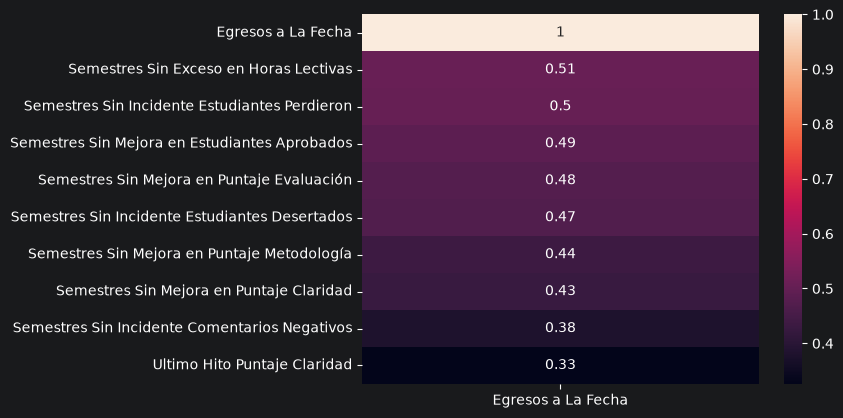

In [12]:
sns.heatmap(chosen_corrs_egr, annot=True)

<Axes: >

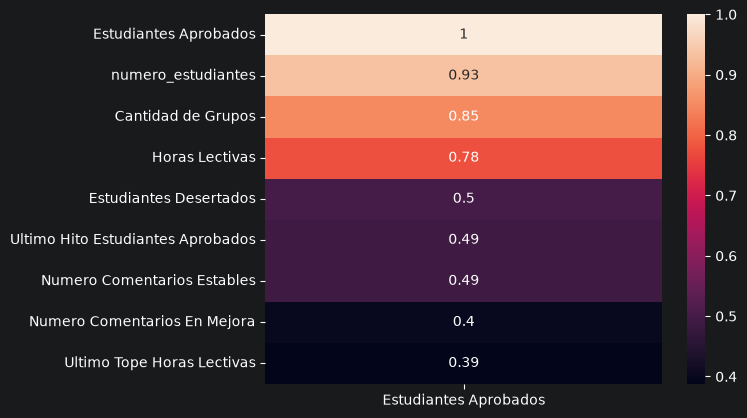

In [13]:
sns.heatmap(chosen_corrs_est, annot=True)

In [14]:
seguimiento_asignaturas = (
    df.groupby(["asignatura", "semestre"], as_index=False)
    .agg(
        Cantidad_de_Docentes=("id_docente", "nunique"),
        Cantidad_de_Grupos=("semestre", "size"), # Counts rows per group
        numero_estudiantes=("numero_estudiantes", "sum"),
        Asistencia_Tipica_Estudiantes=("promedio_asistencias_estudiantes", "sum"),
        Horas_Lectivas=("Horas Lectivas Totales", "sum"),
        Estudiantes_Aprobados=("numero_estudiantes_aprobaron", "sum"),
        Estudiantes_Perdieron=("numero_estudiantes_perdieron", "sum"),
        Estudiantes_Desistieron=("numero_estudiantes_desistieron", "sum"),
        Clases_Dictadas=("clases_dictadas", "sum"),
        # Franja_Horaria=("franja_horaria", lambda x: "Mixta" if len(x.dropna().unique()) > 1 else x[0]),
    )
    .rename(columns={
        "Cantidad_de_Grupos": "Cantidad de Grupos",
        "Cantidad_de_Docentes": "Cantidad de Docentes",
        "Asistencia_Tipica_Estudiantes": "Asistencia Típica de Estudiantes",
        "Horas_Lectivas": "Horas Lectivas",
        "Estudiantes_Aprobados": "Estudiantes Aprobados",
        "Estudiantes_Perdieron": "Estudiantes Que Perdieron",
        "Estudiantes_Desistieron": "Estudiantes Que Desistieron",
        "Clases_Dictadas": "Clases Dictadas",
        # "Franja_Horaria": "Franja Horaria",
    })
    .sort_values(by=["asignatura", "semestre"], ascending=[True, True])
)

seguimiento_asignaturas["Cantidad de Docentes"] = seguimiento_asignaturas["Cantidad de Docentes"].astype("Int64")
seguimiento_asignaturas["Cantidad de Grupos"] = seguimiento_asignaturas["Cantidad de Grupos"].astype("Int64")
seguimiento_asignaturas["numero_estudiantes"] = seguimiento_asignaturas["numero_estudiantes"].astype("Int64")

seguimiento_asignaturas["Asistencia Típica de Estudiantes"] = seguimiento_asignaturas["Asistencia Típica de Estudiantes"].astype("Float64")
seguimiento_asignaturas["Horas Lectivas"] = seguimiento_asignaturas["Horas Lectivas"].astype("Int64")
seguimiento_asignaturas["Estudiantes Aprobados"] = seguimiento_asignaturas["Estudiantes Aprobados"].astype("Int64")
seguimiento_asignaturas["Clases Dictadas"] = seguimiento_asignaturas["Clases Dictadas"].astype("Int64")

# seguimiento_asignaturas["Franja Horaria"] = seguimiento_asignaturas["Franja Horaria"].astype("category")

seguimiento_asignaturas = seguimiento_asignaturas.convert_dtypes()
seguimiento_asignaturas


,asignatura,semestre,Cantidad de Docentes,Cantidad de Grupos,numero_estudiantes,Asistencia Típica de Estudiantes,Horas Lectivas,Estudiantes Aprobados,Estudiantes Que Perdieron,Estudiantes Que Desistieron,Clases Dictadas
0,Bases de Datos,2020Q1,31,56,1558,1321.18,4158,1073,284,201,1741
1,Bases de Datos,2020Q3,35,60,1739,1328.74,4246,1228,320,191,1771
2,Bases de Datos,2021Q1,34,58,1768,1300.15,4076,1204,341,223,1765
3,Bases de Datos,2021Q3,33,48,1405,1102.92,3350,955,295,155,1487
4,Bases de Datos,2022Q1,36,48,1402,1109.2,3621,982,258,162,1474
5,Bases de Datos,2022Q3,28,51,1588,1088.39,3484,1060,349,179,1452
6,Bases de Datos,2023Q1,35,60,1768,1203.58,3944,1246,336,186,1558
7,Bases de Datos,2023Q3,32,47,1474,975.15,3259,1006,302,166,1323
8,Estructuras de Datos,2020Q1,36,66,2038,1557.75,4776,1467,398,173,2037
9,Estructuras de Datos,2020Q3,30,54,1558,1258.13,4079,1080,322,156,1693


In [15]:
corr_asign = seguimiento_asignaturas.select_dtypes(include='number').corr()

<Axes: >

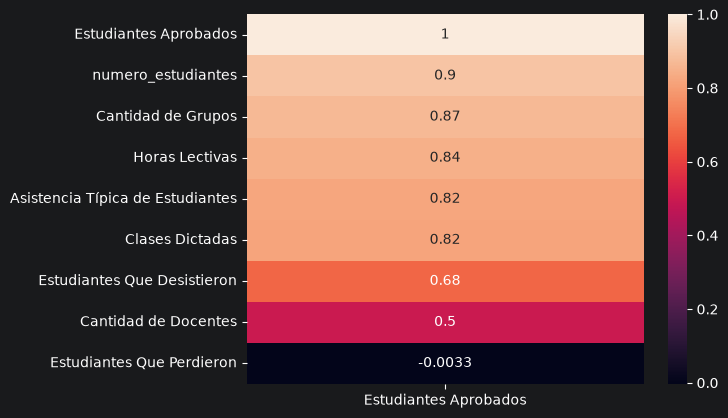

In [16]:
sns.heatmap(corr_asign.loc[:, ["Estudiantes Aprobados"]].sort_values(["Estudiantes Aprobados"], ascending=False), annot=True)

<Axes: >

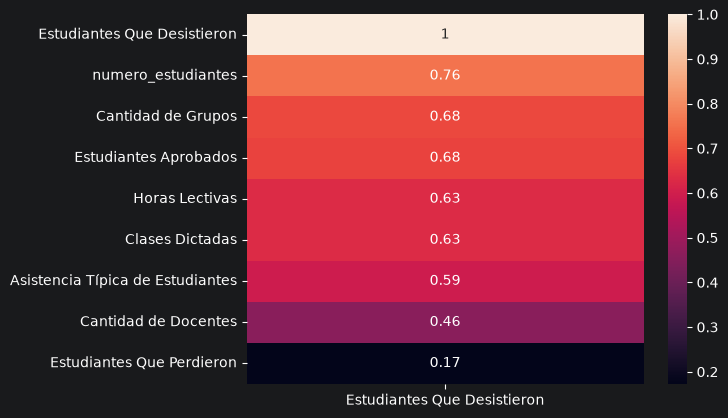

In [17]:
sns.heatmap(corr_asign.loc[:, ["Estudiantes Que Desistieron"]].sort_values(["Estudiantes Que Desistieron"], ascending=False), annot=True)

<Axes: >

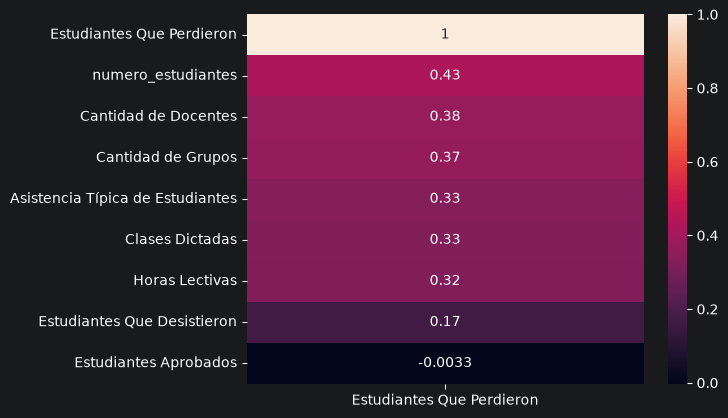

In [18]:
sns.heatmap(corr_asign.loc[:, ["Estudiantes Que Perdieron"]].sort_values(["Estudiantes Que Perdieron"], ascending=False), annot=True)